# Notebook 5: Tabular Feature Engineering

## Objective
Engineer structured clinical features from MIMIC-IV data to complement text embeddings. Create a normalized feature matrix capturing patient demographics, admission characteristics, comorbidity burden, and procedure complexity.

## Input Data
- `sample_10k_admissions_with_notes.csv` (10,000 admissions from Notebook 4)
- `diagnoses_icd.csv` - ICD diagnosis codes (comorbidities)
- `procedures_icd.csv` - Procedure codes

## Process

### 1. **Baseline Demographic & Admission Features**
Extract features already present in admissions data:
- **Demographics**: Race (33 categories), marital status (4), language (25), insurance (5)
- **Admission context**: Admission type (9 types), admission location (11), discharge location (9)
- **Time features**: Length of stay (continuous)

Encoding strategy:
- Categorical variables → One-hot encoding
- Continuous variables → Keep as is, standardize later

### 2. **Comorbidity Features**
From `diagnoses_icd.csv`:
- **num_diagnoses**: Total ICD diagnosis codes per admission (proxy for comorbidity burden)
- Range: 0-42 diagnoses
- Mean: 12.0 diagnoses per admission
- Most common: Hypertension (4019), hyperlipidemia (2724), coronary atherosclerosis (41401)

### 3. **Procedure Complexity Features**
From `procedures_icd.csv`:
- **num_procedures**: Total procedures performed during admission
- Range: 0-33 procedures
- Mean: 1.6 procedures per admission
- Reflects clinical intervention intensity

### 4. **Feature Standardization**
- Apply StandardScaler to all features
- Centers features to mean=0, std=1
- Ensures features on different scales contribute equally to model

## Output
- `tabular_features_sample_10k.npz` - Standardized feature matrix (9,999 × 26)
- `tabular_feature_names.txt` - Human-readable feature name mapping

## Final Feature Set (26 features)

### Continuous Features (3):
1. `los_days` - Length of stay
2. `num_diagnoses` - Diagnosis count
3. `num_procedures` - Procedure count

### Categorical Features (23 one-hot encoded):
- Admission type (9): ELECTIVE, URGENT, EMERGENCY, OBSERVATION, etc.
- Insurance (5): Medicare, Medicaid, Private, Other, No charge
- Discharge location (9): HOME, REHAB, SKILLED NURSING, DIED, etc.

## Key Findings

### Feature-Readmission Correlations
Analysis shows which features correlate with 30-day readmission:
- Length of stay: Longer stays associated with readmission risk
- Comorbidity burden: More diagnoses → higher readmission risk
- Discharge location: Certain destinations (SNF, rehab) signal higher risk

### Data Availability
- All 9,999 admissions have demographic/admission features
- 120,313 diagnosis records (avg 12 per admission)
- 16,288 procedure records (avg 1.6 per admission)

## Feature Engineering Philosophy

### What We Included:
- **Demographics**: Captures patient characteristics
- **Admission context**: How/why patient arrived, where they went
- **Clinical complexity**: Comorbidity burden, procedure intensity
- **Time**: Length of stay

### What We Didn't Include (Yet):
- **Lab values**: Would require labevents.csv (2.4 GB)
- **Medications**: Would require prescriptions.csv
- **Vital signs**: Not in current data
- **Specific diagnoses/procedures**: Too sparse, would create thousands of features

### Design Decisions:
1. **Count-based features** (num_diagnoses, num_procedures) rather than individual codes
   - Avoids extreme sparsity (thousands of unique ICD codes)
   - Captures overall clinical complexity
   - More generalizable

2. **One-hot encoding** for categorical variables
   - Standard ML practice for nominal categories
   - Creates interpretable binary features
   - Works well with neural networks and tree models

3. **Standardization** for continuous features
   - Critical for neural networks
   - Ensures all features contribute equally
   - Prevents LOS (range 0-122) from dominating small counts (0-42)

## Limitations
- **Limited feature set**: Only 26 features (many papers use 100+)
- **No temporal dynamics**: Features are static snapshots
- **Missing clinical depth**: No labs, vitals, or medication details
- **Coarse aggregation**: Count-based features lose specific diagnostic information

## Why This Is Still Useful
Despite limitations, these 26 features capture:
- **Strong signal**: Comorbidity and LOS are known readmission predictors
- **Demographic risk factors**: Insurance, discharge location matter
- **Baseline for comparison**: Can test multimodal gains over text-only models

## Next Step
Notebook 6 will encode temporal event sequences from the 22MCTS timestamped events to capture disease progression patterns over time.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
print("Libraries imported")

Libraries imported


In [3]:
DATA_DIR = Path('/content/drive/MyDrive/MIDS/w266/Final Project/data')
OUTPUT_DIR = Path('/content/drive/MyDrive/MIDS/w266/Final Project/output')
EMBEDDINGS_DIR = OUTPUT_DIR / 'embeddings'

print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Data directory: /content/drive/MyDrive/MIDS/w266/Final Project/data
Output directory: /content/drive/MyDrive/MIDS/w266/Final Project/output


In [4]:
# Load the 10K sample we created in Notebook 4
print("Loading 10K sample with notes...")
sample_df = pd.read_csv(OUTPUT_DIR / 'sample_10k_admissions_with_notes.csv')

print(f"Loaded {len(sample_df):,} admissions")
print(f"Shape: {sample_df.shape}")
print(f"\nColumns available:")
print(sample_df.columns.tolist())

Loading 10K sample with notes...
Loaded 9,999 admissions
Shape: (9999, 19)

Columns available:
['subject_id', 'hadm_id', 'admittime', 'dischtime', 'admission_type', 'admission_location', 'discharge_location', 'insurance', 'language', 'marital_status', 'race', 'los_days', 'readmitted_30day', 'days_to_readmission', 'readmission_hadm_id', 'note_id', 'charttime', 'storetime', 'text']


In [5]:
# See what features we already have from the admissions table
print("\nExisting features in sample:")
print("-"*60)

# Demographics
print("\nDemographic features:")
demographic_cols = ['subject_id', 'hadm_id', 'race', 'gender', 'marital_status',
                    'language', 'insurance']
for col in demographic_cols:
    if col in sample_df.columns:
        print(f"  {col}: {sample_df[col].nunique()} unique values")

# Admission info
print("\nAdmission features:")
admission_cols = ['admission_type', 'admission_location', 'discharge_location']
for col in admission_cols:
    if col in sample_df.columns:
        print(f"  {col}: {sample_df[col].nunique()} unique values")

# Time features
print("\nTime features:")
time_cols = ['admittime', 'dischtime', 'los_days']
for col in time_cols:
    if col in sample_df.columns:
        print(f"  {col}")

# Label
print(f"\nLabel: readmitted_30day")
print(sample_df['readmitted_30day'].value_counts())


Existing features in sample:
------------------------------------------------------------

Demographic features:
  subject_id: 9342 unique values
  hadm_id: 9999 unique values
  race: 33 unique values
  marital_status: 4 unique values
  language: 25 unique values
  insurance: 5 unique values

Admission features:
  admission_type: 9 unique values
  admission_location: 11 unique values
  discharge_location: 9 unique values

Time features:
  admittime
  dischtime
  los_days

Label: readmitted_30day
readmitted_30day
0    7935
1    2064
Name: count, dtype: int64


In [7]:
# Check what other files we downloaded
print("\nAvailable data files:")
print("-"*60)

available_files = []
for file in sorted(DATA_DIR.glob('*.csv')):
    size_mb = file.stat().st_size / (1024 * 1024)
    print(f"  {file.name:<35} {size_mb:>8.1f} MB")
    available_files.append(file.name)

print("\nFiles we can use for feature engineering:")
useful_files = [
    'diagnoses_icd.csv',
    'd_icd_diagnoses.csv',
    'procedures_icd.csv',
    'd_icd_procedures.csv',
    'services.csv',
    'drgcodes.csv',
    'd_labitems.csv'
]

print("\nFiles we have:")
for f in useful_files:
    if f in available_files:
        print(f"  ✓ {f}")
    else:
        print(f"  ✗ {f} - not available")


Available data files:
------------------------------------------------------------
  admissions.csv                          89.8 MB
  clinical_event_timestamp.csv           835.2 MB
  d_icd_diagnoses.csv                      8.7 MB
  d_icd_procedures.csv                     7.1 MB
  d_labitems.csv                           0.1 MB
  diagnoses_icd.csv                      173.0 MB
  discharge.csv                         3365.3 MB
  drgcodes.csv                            52.2 MB
  patients.csv                            11.5 MB
  procedures_icd.csv                      32.7 MB
  services.csv                            24.8 MB

Files we can use for feature engineering:

Files we have:
  ✓ diagnoses_icd.csv
  ✓ d_icd_diagnoses.csv
  ✓ procedures_icd.csv
  ✓ d_icd_procedures.csv
  ✓ services.csv
  ✓ drgcodes.csv
  ✓ d_labitems.csv


In [8]:
# Start with features we already have in the admissions data
print("Engineering features from existing columns...")

features_df = sample_df[['hadm_id', 'subject_id', 'readmitted_30day']].copy()

# 1. Length of stay (already calculated)
features_df['los_days'] = sample_df['los_days']

# 2. Admission type - one-hot encode
admission_type_dummies = pd.get_dummies(sample_df['admission_type'], prefix='admit_type')
features_df = pd.concat([features_df, admission_type_dummies], axis=1)

# 3. Insurance type - one-hot encode
insurance_dummies = pd.get_dummies(sample_df['insurance'], prefix='insurance')
features_df = pd.concat([features_df, insurance_dummies], axis=1)

# 4. Discharge location - one-hot encode
discharge_dummies = pd.get_dummies(sample_df['discharge_location'], prefix='discharge_loc')
features_df = pd.concat([features_df, discharge_dummies], axis=1)

print(f"\nFeatures created: {features_df.shape[1] - 3} features")  # -3 for hadm_id, subject_id, label
print(f"Total columns: {features_df.shape[1]}")

Engineering features from existing columns...

Features created: 24 features
Total columns: 27


In [9]:
# Show what features we have so far
print("\nCurrent feature summary:")
print("-"*60)

# Exclude ID and label columns
feature_cols = [col for col in features_df.columns
                if col not in ['hadm_id', 'subject_id', 'readmitted_30day']]

print(f"Total features: {len(feature_cols)}")
print(f"\nFeature breakdown:")
print(f"  Length of stay: 1")
print(f"  Admission type: {sum('admit_type' in col for col in feature_cols)}")
print(f"  Insurance: {sum('insurance' in col for col in feature_cols)}")
print(f"  Discharge location: {sum('discharge_loc' in col for col in feature_cols)}")

print(f"\nFeature columns:")
for col in feature_cols:
    print(f"  {col}")


Current feature summary:
------------------------------------------------------------
Total features: 24

Feature breakdown:
  Length of stay: 1
  Admission type: 9
  Insurance: 5
  Discharge location: 9

Feature columns:
  los_days
  admit_type_AMBULATORY OBSERVATION
  admit_type_DIRECT EMER.
  admit_type_DIRECT OBSERVATION
  admit_type_ELECTIVE
  admit_type_EU OBSERVATION
  admit_type_EW EMER.
  admit_type_OBSERVATION ADMIT
  admit_type_SURGICAL SAME DAY ADMISSION
  admit_type_URGENT
  insurance_Medicaid
  insurance_Medicare
  insurance_No charge
  insurance_Other
  insurance_Private
  discharge_loc_AGAINST ADVICE
  discharge_loc_ASSISTED LIVING
  discharge_loc_DIED
  discharge_loc_HOME
  discharge_loc_HOME HEALTH CARE
  discharge_loc_OTHER FACILITY
  discharge_loc_PSYCH FACILITY
  discharge_loc_REHAB
  discharge_loc_SKILLED NURSING FACILITY


In [10]:
# Add diagnosis features if we have the data
if 'diagnoses_icd.csv' in available_files:
    print("\nLoading diagnosis data...")
    diagnoses = pd.read_csv(DATA_DIR / 'diagnoses_icd.csv')

    print(f"Total diagnosis records: {len(diagnoses):,}")
    print(f"Unique admissions with diagnoses: {diagnoses['hadm_id'].nunique():,}")

    # Filter to our sample
    sample_diagnoses = diagnoses[diagnoses['hadm_id'].isin(features_df['hadm_id'])]
    print(f"Diagnoses for our sample: {len(sample_diagnoses):,}")

    # Count number of diagnoses per admission (comorbidity count)
    diagnosis_counts = sample_diagnoses.groupby('hadm_id').size().reset_index(name='num_diagnoses')
    features_df = features_df.merge(diagnosis_counts, on='hadm_id', how='left')
    features_df['num_diagnoses'] = features_df['num_diagnoses'].fillna(0)

    print(f"\nAdded feature: num_diagnoses")
    print(f"Range: {features_df['num_diagnoses'].min():.0f} - {features_df['num_diagnoses'].max():.0f}")
    print(f"Mean: {features_df['num_diagnoses'].mean():.1f}")

    # Optionally: Add top diagnosis categories as features
    print(f"\nTop 10 most common diagnoses:")
    print(sample_diagnoses['icd_code'].value_counts().head(10))

else:
    print("\nDiagnosis data not available - skipping")


Loading diagnosis data...
Total diagnosis records: 6,364,488
Unique admissions with diagnoses: 545,497
Diagnoses for our sample: 120,313

Added feature: num_diagnoses
Range: 0 - 42
Mean: 12.0

Top 10 most common diagnoses:
icd_code
4019      2493
2724      1733
I10       1356
53081     1319
E785      1263
25000     1017
Z87891    1016
41401      923
42731      911
K219       910
Name: count, dtype: int64


In [11]:
# Add procedure features if we have the data
if 'procedures_icd.csv' in available_files:
    print("\nLoading procedure data...")
    procedures = pd.read_csv(DATA_DIR / 'procedures_icd.csv')

    print(f"Total procedure records: {len(procedures):,}")

    # Filter to our sample
    sample_procedures = procedures[procedures['hadm_id'].isin(features_df['hadm_id'])]
    print(f"Procedures for our sample: {len(sample_procedures):,}")

    # Count number of procedures per admission
    procedure_counts = sample_procedures.groupby('hadm_id').size().reset_index(name='num_procedures')
    features_df = features_df.merge(procedure_counts, on='hadm_id', how='left')
    features_df['num_procedures'] = features_df['num_procedures'].fillna(0)

    print(f"\nAdded feature: num_procedures")
    print(f"Range: {features_df['num_procedures'].min():.0f} - {features_df['num_procedures'].max():.0f}")
    print(f"Mean: {features_df['num_procedures'].mean():.1f}")

else:
    print("\nProcedure data not available - skipping")


Loading procedure data...
Total procedure records: 859,655
Procedures for our sample: 16,288

Added feature: num_procedures
Range: 0 - 33
Mean: 1.6


In [12]:
# Show statistics for all numeric features
print("\nNumeric feature statistics:")
print("-"*60)

numeric_features = features_df.select_dtypes(include=[np.number]).columns
numeric_features = [col for col in numeric_features
                   if col not in ['hadm_id', 'subject_id', 'readmitted_30day']]

print(features_df[numeric_features].describe())


Numeric feature statistics:
------------------------------------------------------------
          los_days  num_diagnoses  num_procedures
count  9999.000000    9999.000000     9999.000000
mean      5.027920      12.032503        1.628963
std       6.121092       6.824907        2.408548
min       0.022917       0.000000        0.000000
25%       1.803472       7.000000        0.000000
50%       3.371528      11.000000        1.000000
75%       5.942708      16.000000        2.000000
max     122.734722      42.000000       33.000000



Visualizing features by readmission status...


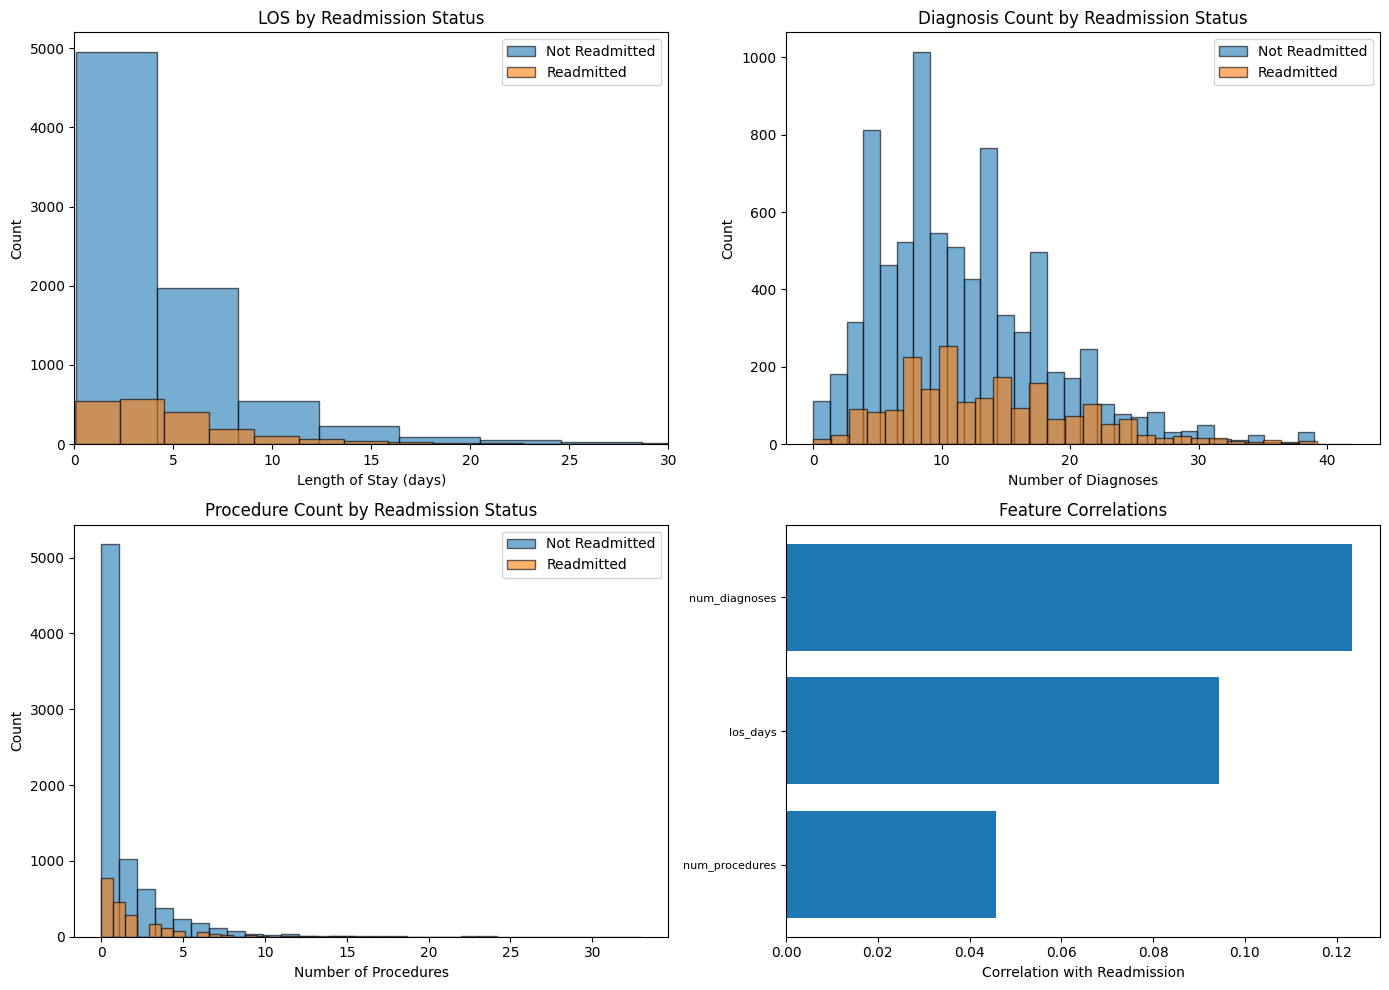

In [13]:
# Visualize key features by readmission status
print("\nVisualizing features by readmission status...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# LOS
axes[0, 0].hist(features_df[features_df['readmitted_30day']==0]['los_days'],
                bins=30, alpha=0.6, label='Not Readmitted', edgecolor='black')
axes[0, 0].hist(features_df[features_df['readmitted_30day']==1]['los_days'],
                bins=30, alpha=0.6, label='Readmitted', edgecolor='black')
axes[0, 0].set_xlabel('Length of Stay (days)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('LOS by Readmission Status')
axes[0, 0].legend()
axes[0, 0].set_xlim(0, 30)

# Num diagnoses
if 'num_diagnoses' in features_df.columns:
    axes[0, 1].hist(features_df[features_df['readmitted_30day']==0]['num_diagnoses'],
                    bins=30, alpha=0.6, label='Not Readmitted', edgecolor='black')
    axes[0, 1].hist(features_df[features_df['readmitted_30day']==1]['num_diagnoses'],
                    bins=30, alpha=0.6, label='Readmitted', edgecolor='black')
    axes[0, 1].set_xlabel('Number of Diagnoses')
    axes[0, 1].set_ylabel('Count')
    axes[0, 1].set_title('Diagnosis Count by Readmission Status')
    axes[0, 1].legend()

# Num procedures
if 'num_procedures' in features_df.columns:
    axes[1, 0].hist(features_df[features_df['readmitted_30day']==0]['num_procedures'],
                    bins=30, alpha=0.6, label='Not Readmitted', edgecolor='black')
    axes[1, 0].hist(features_df[features_df['readmitted_30day']==1]['num_procedures'],
                    bins=30, alpha=0.6, label='Readmitted', edgecolor='black')
    axes[1, 0].set_xlabel('Number of Procedures')
    axes[1, 0].set_ylabel('Count')
    axes[1, 0].set_title('Procedure Count by Readmission Status')
    axes[1, 0].legend()

# Feature correlation with readmission
feature_corr = features_df[numeric_features + ['readmitted_30day']].corr()['readmitted_30day'].drop('readmitted_30day').sort_values()
axes[1, 1].barh(range(len(feature_corr)), feature_corr.values)
axes[1, 1].set_yticks(range(len(feature_corr)))
axes[1, 1].set_yticklabels(feature_corr.index, fontsize=8)
axes[1, 1].set_xlabel('Correlation with Readmission')
axes[1, 1].set_title('Feature Correlations')
axes[1, 1].axvline(0, color='black', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'tabular_features_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Separate features from identifiers and label
print("\nPreparing final feature matrix...")

# Get feature columns (exclude IDs and label)
feature_cols = [col for col in features_df.columns
                if col not in ['hadm_id', 'subject_id', 'readmitted_30day']]

X = features_df[feature_cols].values
y = features_df['readmitted_30day'].values
hadm_ids = features_df['hadm_id'].values

print(f"\nFeature matrix shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Feature names: {len(feature_cols)}")


Preparing final feature matrix...

Feature matrix shape: (9999, 26)
Labels shape: (9999,)
Feature names: 26


In [15]:
# Standardize numeric features
print("\nStandardizing features...")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Scaled feature matrix shape: {X_scaled.shape}")
print(f"\nFeature statistics after scaling:")
print(f"Mean: {X_scaled.mean(axis=0)[:5]}")  # Show first 5
print(f"Std: {X_scaled.std(axis=0)[:5]}")


Standardizing features...
Scaled feature matrix shape: (9999, 26)

Feature statistics after scaling:
Mean: [-7.95887453e-17 -1.31463552e-17  0.00000000e+00  6.85742314e-17
 -2.84245519e-17]
Std: [1. 1. 1. 1. 1.]


In [16]:
# Save the engineered features
output_file = OUTPUT_DIR / 'tabular_features_sample_10k.npz'
feature_names_file = OUTPUT_DIR / 'tabular_feature_names.txt'

# Save features
np.savez_compressed(
    output_file,
    features=X_scaled,
    labels=y,
    hadm_ids=hadm_ids,
    feature_names=np.array(feature_cols)
)

# Save feature names as text for reference
with open(feature_names_file, 'w') as f:
    for i, name in enumerate(feature_cols):
        f.write(f"{i}: {name}\n")

print(f"\nSaved tabular features to: {output_file}")
print(f"Saved feature names to: {feature_names_file}")
print(f"File size: {output_file.stat().st_size / (1024*1024):.2f} MB")


Saved tabular features to: /content/drive/MyDrive/MIDS/w266/Final Project/output/tabular_features_sample_10k.npz
Saved feature names to: /content/drive/MyDrive/MIDS/w266/Final Project/output/tabular_feature_names.txt
File size: 0.15 MB


In [17]:
print("\n" + "="*60)
print("NOTEBOOK 5 COMPLETE: TABULAR FEATURES ENGINEERED")
print("="*60)

print(f"\nSummary:")
print(f"  Admissions: {len(features_df):,}")
print(f"  Total features: {len(feature_cols)}")
print(f"  Feature matrix: {X_scaled.shape}")

print(f"\nFeature breakdown:")
print(f"  Continuous: {sum('los' in col or 'num' in col for col in feature_cols)}")
print(f"  One-hot encoded: {len(feature_cols) - sum('los' in col or 'num' in col for col in feature_cols)}")

print(f"\nOutputs:")
print(f"  Features: {output_file}")
print(f"  Feature names: {feature_names_file}")

print(f"\nData ready for:")
print(f"  - Text embeddings (768-dim) from Notebook 4")
print(f"  - Tabular features ({len(feature_cols)}-dim) from this notebook")
print(f"  - Next: Notebook 6 for temporal event encoding")
print(f"  - Then: Notebook 7 for multimodal fusion")


NOTEBOOK 5 COMPLETE: TABULAR FEATURES ENGINEERED

Summary:
  Admissions: 9,999
  Total features: 26
  Feature matrix: (9999, 26)

Feature breakdown:
  Continuous: 3
  One-hot encoded: 23

Outputs:
  Features: /content/drive/MyDrive/MIDS/w266/Final Project/output/tabular_features_sample_10k.npz
  Feature names: /content/drive/MyDrive/MIDS/w266/Final Project/output/tabular_feature_names.txt

Data ready for:
  - Text embeddings (768-dim) from Notebook 4
  - Tabular features (26-dim) from this notebook
  - Next: Notebook 6 for temporal event encoding
  - Then: Notebook 7 for multimodal fusion
